# Baseline 1: Xception

This notebook contains the code for training the **Xception** model on our preprocessed face crops. Xception is the standard frame-level baseline from the original FaceForensics++ paper (Rossler et al., 2019). So, this gives us our first SOTA comparison number.

It is importanmt to note that Xception is frame-level. That is, it doesn't model time. For each video, we run it on every frame independently and average the predictions to get a clip-level score.

**Approach:** Frame-level CNN. Run Xception on each of the 24 frames, average the per-frame logits to get a single clip-level prediction.

**Reference:** Rossler et al., *"FaceForensics++: Learning to Detect Manipulated Facial Images"*, ICCV 2019.

### To view TensorBoard
In PowerShell, use the following command:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.

## 1. Setup

In [1]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random

import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import timm

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    make_balanced_sampler,
    run_training,
    evaluate,
    load_checkpoint,
    plot_training_curves,
)

In [2]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True


In [3]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [4]:
# Set the hyper-parameter
model_name = "xception_baseline"
# number_of_epochs = 2 # For dry-run
number_of_epochs = 25
batch_size = 8 # 8 clips × 24 frames = 192 frames per batch. We can furthe rincrease it, but we are limited by 16GB VRAM
subset_size = None # use full dataset
learning_rate = 1e-4
weight_decay = 1e-4
early_stopping_patience = 5

## 2. Build datasets and dataloaders

We use the balanced sampler on the train split to oversample reals (since fakes outnumber them 4:1).

In [5]:
# Build the dataset
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

train_dataset = DeepfakeClipDataset(splits_json_path, "train", PREPROCESSED_TENSORS_DIR_PATH, training_augment=True)
validation_dataset = DeepfakeClipDataset(splits_json_path, "validation", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)
test_dataset = DeepfakeClipDataset(splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)

print(f"Train: {len(train_dataset)} clips")
print(f"validation:   {len(validation_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

Train: 2799 clips
validation:   349 clips
Test:  351 clips


In [6]:
# Make the training dataset balanced
train_sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

## 3. Define the model

We use the Xception backbone from `timm` (pretrained on ImageNet), then replace its classifier with a single-output head, then wrap it so it accepts clip tensors of shape `[B, T, 3, H, W]` and averages over the time dimension.

In [7]:
class XceptionFrameAverager(nn.Module):
    """Run Xception on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        # timm's 'legacy_xception' is the ImageNet-pretrained Xception.
        self.backbone = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        
        # Flatten time into batch: [B*T, 3, H, W]
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        
        # Run Xception on every frame: Output: [B*T, 1]
        per_frame_logits = self.backbone(flat_frames)
        
        # Reshape back: [B, T, 1] and average over time
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)  # [B, 1]
        return clip_logits


model = XceptionFrameAverager(pretrained=True).to(DEVICE)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_parameters:,}  ({num_parameters/1e6:.1f}M)")

Trainable parameters: 20,809,001  (20.8M)


## 4. Optimizer, scheduler, loss

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# We use Cosine annealing as it gradually decays the LR over the training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs)

loss_function = nn.BCEWithLogitsLoss()

print(f"Optimizer: AdamW, lr={learning_rate}, weight_decay={weight_decay}")
print(f"Scheduler: CosineAnnealingLR over {number_of_epochs} epochs")
print(f"Loss: BCEWithLogitsLoss")

Optimizer: AdamW, lr=0.0001, weight_decay=0.0001
Scheduler: CosineAnnealingLR over 25 epochs
Loss: BCEWithLogitsLoss


## 5. Train

The `run_training` helper from `utils.py` handles the full loop. That is, training epochs, validation, TensorBoard logging, early stopping, and saving the best checkpoint.

In [9]:
best_checkpoint_path = run_training(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function,
    device=DEVICE,
    model_name=model_name,
    number_of_epochs=number_of_epochs,
    early_stopping_patience=early_stopping_patience,
    use_mixed_precision=True,
)


Training: xception_baseline
TensorBoard logs: results\xception_baseline\tensorboard
  Run `tensorboard --logdir C:\x-ion\TEST\results` to view live curves.



train:   0%|          | 0/350 [00:00<?, ?it/s]

eval:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch  1/25  train_loss=0.4734  validation_loss=0.3142  validation_auc=0.9500  validation_acc=0.8825  (1588.7s)


train:   0%|          | 0/350 [00:00<?, ?it/s]

...

eval:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 19/25  train_loss=0.0036  validation_loss=0.1216  validation_auc=0.9929  validation_acc=0.9771  (1486.4s)


train:   0%|          | 0/350 [00:00<?, ?it/s]

eval:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 20/25  train_loss=0.0030  validation_loss=0.1043  validation_auc=0.9938  validation_acc=0.9828  (1486.3s)

Early stopping at epoch 20 (no improvement for 5 epochs).

Training done. Best vvalidation AUC: 0.9951
Best checkpoint: results\xception_baseline\best_model.pt


## 6. Plot training curves

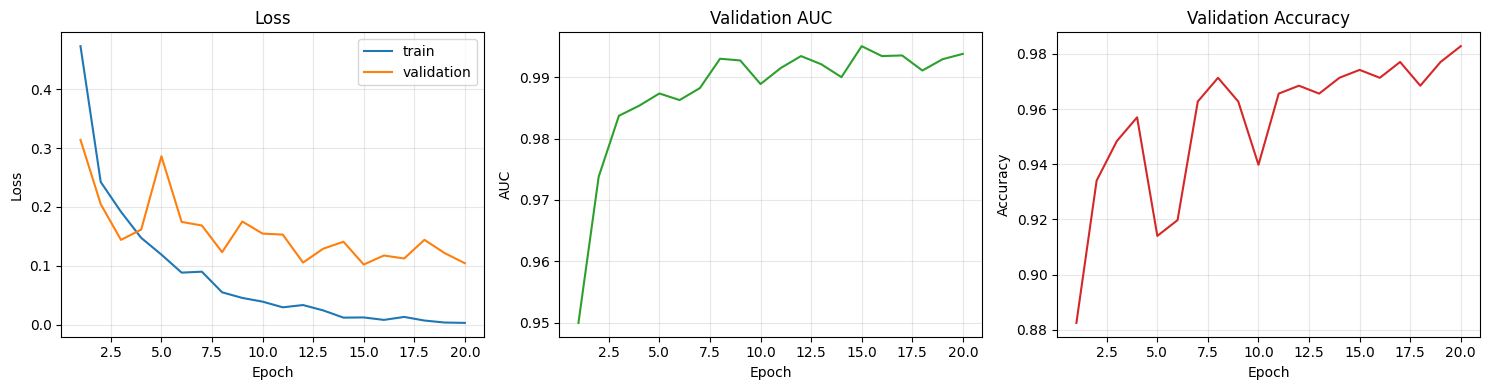

In [10]:
history_path = RESULTS_DIR_PATH / model_name / "training_history.json"
curves_save_path = RESULTS_DIR_PATH / model_name / "training_curves.png"
plot_training_curves(history_path, save_path=curves_save_path)


## 7. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test split. This is the number we'll report in the report.

In [11]:
load_checkpoint(model, best_checkpoint_path, DEVICE)
test_loss, test_metrics, test_predictions = evaluate(model, test_loader, loss_function, DEVICE)

print("\n=== Test set results ===")
print(f"Loss:      {test_loss:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: {test_metrics['confusion_matrix']}")

# Save for later aggregation across all models
test_metrics_save_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
with open(test_metrics_save_path, "w") as f:
    json.dump({"test_loss": test_loss, "test_metrics": test_metrics}, f, indent=2)

# Also save per-sample predictions for the per-class breakdown later
predictions_save_path = RESULTS_DIR_PATH / model_name / "test_predictions.json"
with open(predictions_save_path, "w") as f:
    json.dump(test_predictions, f, indent=2)

print(f"\nSaved test metrics to {test_metrics_save_path}")

eval:   0%|          | 0/44 [00:00<?, ?it/s]


=== Test set results ===
Loss:      0.0645
AUC:       0.9944
Accuracy:  0.9744
Precision: 0.9823
Recall:    0.9858
F1:        0.9840
Confusion matrix [[TN, FP], [FN, TP]]: [[65, 5], [4, 277]]

Saved test metrics to results\xception_baseline\final_test_metrics.json


## 8. Per-manipulation breakdown

Split test-set predictions by manipulation method. This will tells us which fake types Xception handles best.

In [12]:
# Group predictions by class name
predictions_by_class = defaultdict(list)
labels_by_class = defaultdict(list)
for probability, true_label, class_name in zip(
    test_predictions["predicted_probs"],
    test_predictions["true_labels"],
    test_predictions["class_names"],
):
    predictions_by_class[class_name].append(probability)
    labels_by_class[class_name].append(true_label)

print("\n=== Per-class accuracy on test set (threshold = 0.5) ===")
print(f"{'Class':<20} {'N':>4}  {'Accuracy':>10}  {'Mean prob':>10}")
print("-" * 50)
for cls_name in sorted(predictions_by_class.keys()):
    probs = np.array(predictions_by_class[cls_name])
    true_labels = np.array(labels_by_class[cls_name])
    predicted = (probs >= 0.5).astype(int)
    accuracy = (predicted == true_labels).mean()
    print(f"{cls_name:<20} {len(probs):>4}  {accuracy:>10.4f}  {probs.mean():>10.4f}")


=== Per-class accuracy on test set (threshold = 0.5) ===
Class                   N    Accuracy   Mean prob
--------------------------------------------------
Deepfakes              71      0.9859      0.9895
Face2Face              70      0.9857      0.9840
FaceSwap               70      1.0000      0.9962
NeuralTextures         70      0.9714      0.9685
original               70      0.9286      0.0690
